In [1]:
# Librerías y funciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from datetime import datetime
import re
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from joblib import parallel_backend
from category_encoders import TargetEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Cargando y dividiendo los datos

df = pd.read_csv('https://raw.githubusercontent.com/gonzalezulises/airbnb-pricing-ml/refs/heads/main/data/raw/airbnb-listings-extract.csv', sep=';', decimal='.')
print(f'Dimensiones totales del dataset: {df.shape}')

# División en entrenamiento y prueba - simple y directo
train, test = train_test_split(df, test_size=0.2, shuffle=True, random_state=42)

# Mostrando información básica
print(f'Dimensiones del dataset de training: {train.shape}')
print(f'Dimensiones del dataset de test: {test.shape}')

# Guardando los conjuntos
train.to_csv('./train.csv', sep=';', decimal='.', index=False)
test.to_csv('./test.csv', sep=';', decimal='.', index=False)

Dimensiones totales del dataset: (14780, 89)
Dimensiones del dataset de training: (11824, 89)
Dimensiones del dataset de test: (2956, 89)


In [4]:
# Limpieza

df = pd.read_csv('./train.csv', sep=';', decimal='.')

not_useful_columns = [
    'ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Thumbnail Url', 'Medium Url', 
    'Picture Url', 'XL Picture Url', 'Host ID', 'Host URL', 'Host Name', 
    'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood', 'Weekly Price', 
    'Monthly Price', 'Calendar Updated', 'Calendar last Scraped', 'First Review', 
    'Last Review', 'Reviews per Month', 'Geolocation', 'Calculated host listings count',
    'Host Listings Count', 'Host Total Listings Count'
]

df.drop(not_useful_columns, axis=1, inplace=True)

In [5]:
somehow_useful_columns_but_droppable_anyway = ['Name', 'Summary', 'Space', 'Description',
       'Neighborhood Overview', 'Notes', 'Transit', 'Access', 'Interaction', 'House Rules',
       'Host Location', 'Host About'
]

df.drop(somehow_useful_columns_but_droppable_anyway, axis=1, inplace=True)

In [6]:
df.apply(lambda x: len(x.unique()))

Experiences Offered                 5
Host Since                       2049
Host Response Time                  5
Host Response Rate                 68
Host Acceptance Rate               12
Host Verifications                188
Street                           1450
Neighbourhood                     352
Neighbourhood Cleansed            444
Neighbourhood Group Cleansed       49
City                              218
State                              93
Zipcode                           552
Market                             42
Smart Location                    225
Country Code                       18
Country                            18
Latitude                        11824
Longitude                       11824
Property Type                      22
Room Type                           3
Accommodates                       16
Bathrooms                          18
Bedrooms                           11
Beds                               17
Bed Type                            5
Amenities   

In [7]:
# Valores nulos por columna
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = pd.concat([missing_values, missing_percent], axis=1, keys=['Valores Nulos', 'Porcentaje'])
print("\nColumnas con más valores nulos (top 15):")
print(missing_df.head(15))


Columnas con más valores nulos (top 15):
                             Valores Nulos  Porcentaje
Has Availability                     11813   99.906969
Host Acceptance Rate                 11791   99.720907
Jurisdiction Names                   11648   98.511502
License                              11553   97.708051
Square Feet                          11353   96.016576
Security Deposit                      6840   57.848444
Cleaning Fee                          4890   41.356563
Neighbourhood                         4190   35.436401
Review Scores Value                   2685   22.708051
Review Scores Location                2685   22.708051
Review Scores Checkin                 2682   22.682679
Review Scores Accuracy                2675   22.623478
Review Scores Cleanliness             2670   22.581191
Review Scores Communication           2668   22.564276
Review Scores Rating                  2655   22.454330


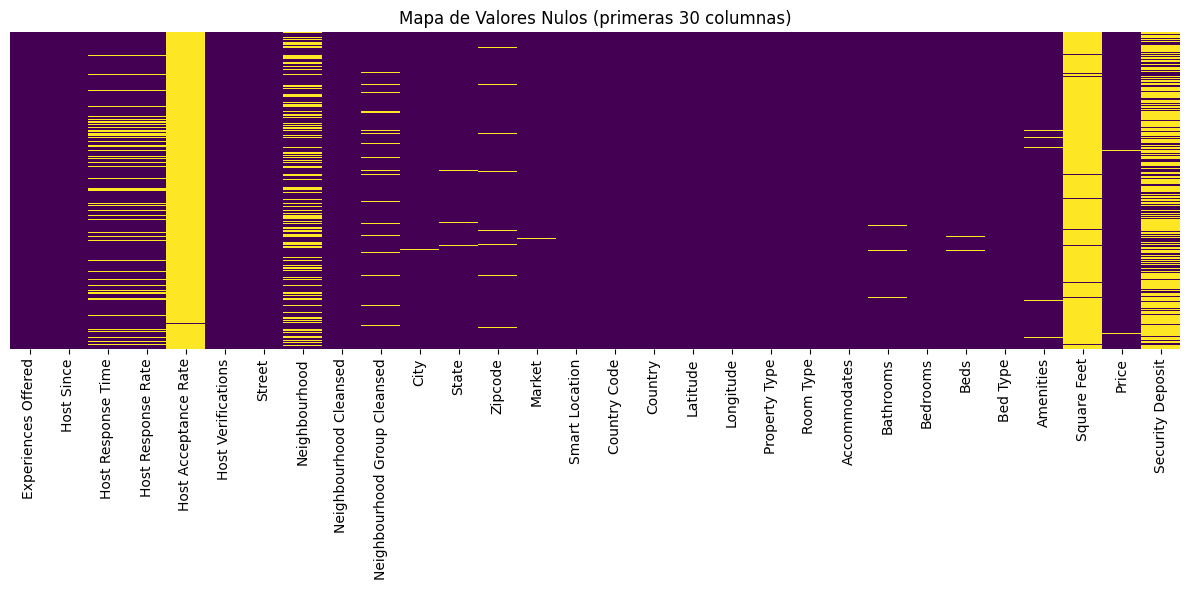

In [8]:
# Visualización de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df.iloc[:, :30].isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Valores Nulos (primeras 30 columnas)')
plt.tight_layout()
plt.show()

In [9]:
df.drop(['Street', 'State', 'Market', 'Smart Location', 'Country', 'Zipcode'], axis=1, inplace=True)

In [10]:
print(f'El dataframe tiene un total de {len(df)} filas.')
len(df) - df.count() # vemos cuántos valores NaN hay por columna


El dataframe tiene un total de 11824 filas.


Experiences Offered                 0
Host Since                          2
Host Response Time               1538
Host Response Rate               1538
Host Acceptance Rate            11791
Host Verifications                  5
Neighbourhood                    4190
Neighbourhood Cleansed              0
Neighbourhood Group Cleansed      793
City                                6
Country Code                        0
Latitude                            0
Longitude                           0
Property Type                       0
Room Type                           0
Accommodates                        0
Bathrooms                          46
Bedrooms                           19
Beds                               36
Bed Type                            0
Amenities                         131
Square Feet                     11353
Price                              12
Security Deposit                 6840
Cleaning Fee                     4890
Guests Included                     0
Extra People

In [11]:
columns_with_too_many_missing_values = [
    'Host Acceptance Rate', 'Square Feet', 'Has Availability', 'License', 'Jurisdiction Names'
]

df.drop(columns_with_too_many_missing_values, axis=1, inplace=True)

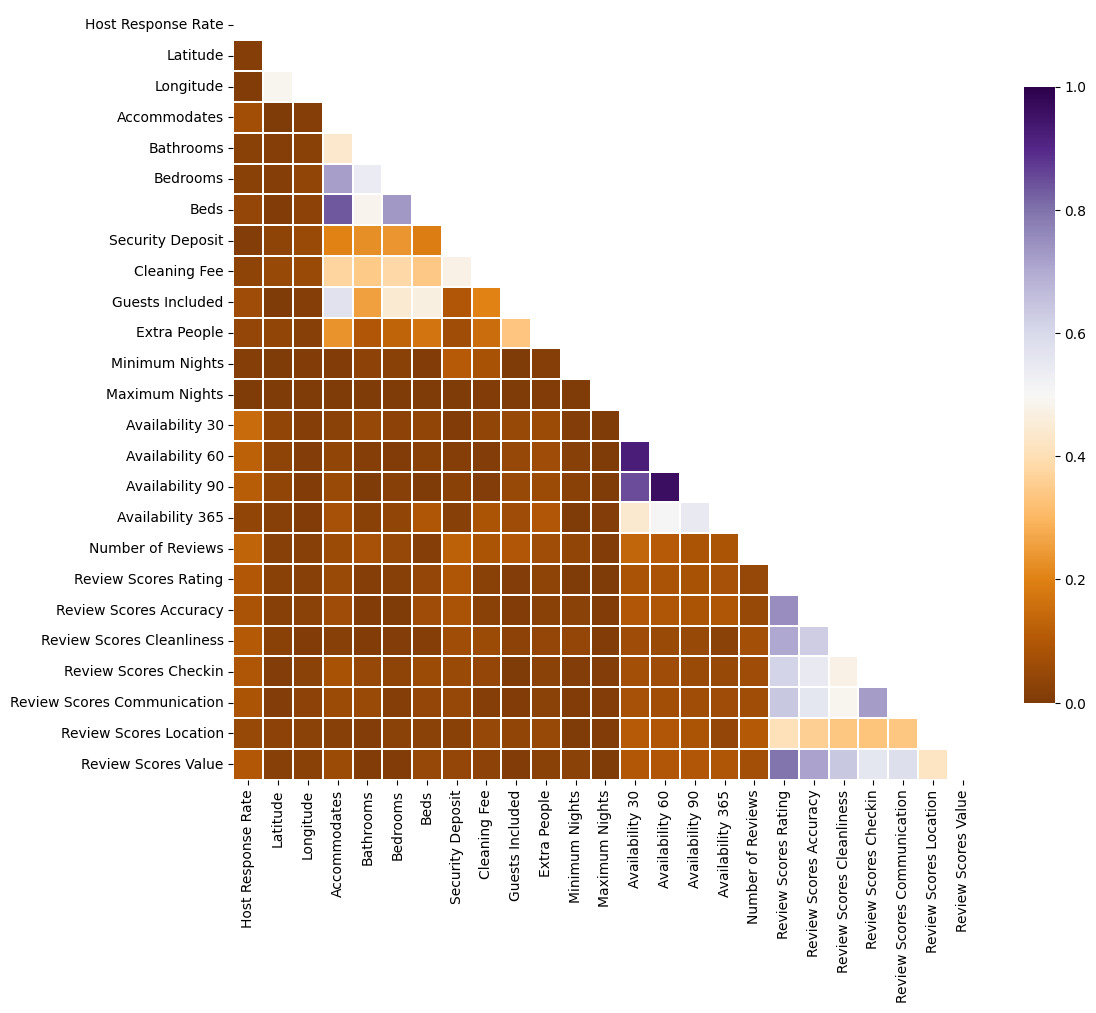

In [12]:
# Visualizando la redundancia
corr = np.abs(df.drop(['Price'], axis=1).corr(numeric_only=True))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="PuOr", cbar_kws={"shrink": .8})
plt.show()

In [13]:
print(f'El dataframe tiene un total de {len(df)} filas.')
len(df) - df.count() # vemos cuántos valores NaN hay por columna

El dataframe tiene un total de 11824 filas.


Experiences Offered                0
Host Since                         2
Host Response Time              1538
Host Response Rate              1538
Host Verifications                 5
Neighbourhood                   4190
Neighbourhood Cleansed             0
Neighbourhood Group Cleansed     793
City                               6
Country Code                       0
Latitude                           0
Longitude                          0
Property Type                      0
Room Type                          0
Accommodates                       0
Bathrooms                         46
Bedrooms                          19
Beds                              36
Bed Type                           0
Amenities                        131
Price                             12
Security Deposit                6840
Cleaning Fee                    4890
Guests Included                    0
Extra People                       0
Minimum Nights                     0
Maximum Nights                     0
A

In [14]:
reviews = df.loc[: , "Review Scores Rating":"Review Scores Value"]
df['Average Review'] = reviews.mean(axis=1)

df.drop(['Availability 30', 'Availability 60', 'Availability 90', 'Review Scores Rating', 
         'Review Scores Accuracy', 'Review Scores Cleanliness', 'Review Scores Checkin',
       'Review Scores Communication', 'Review Scores Location', 'Review Scores Value',
        'Accommodates'], axis=1, inplace=True)

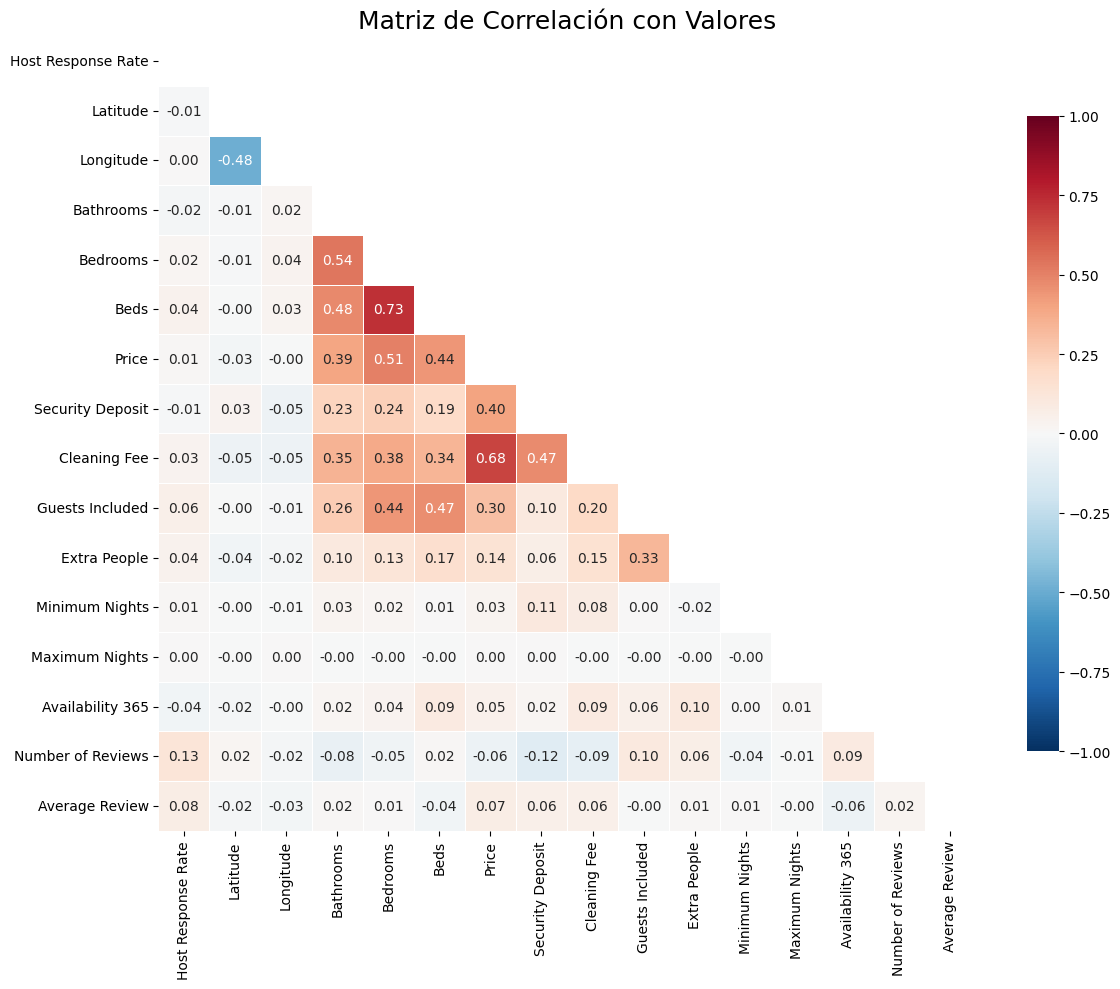

In [15]:
# Mapa de calor de correlación con texto informativo
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
heatmap = sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", 
                    cmap="RdBu_r", vmin=-1, vmax=1, 
                    linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlación con Valores", fontsize=18)
plt.tight_layout()

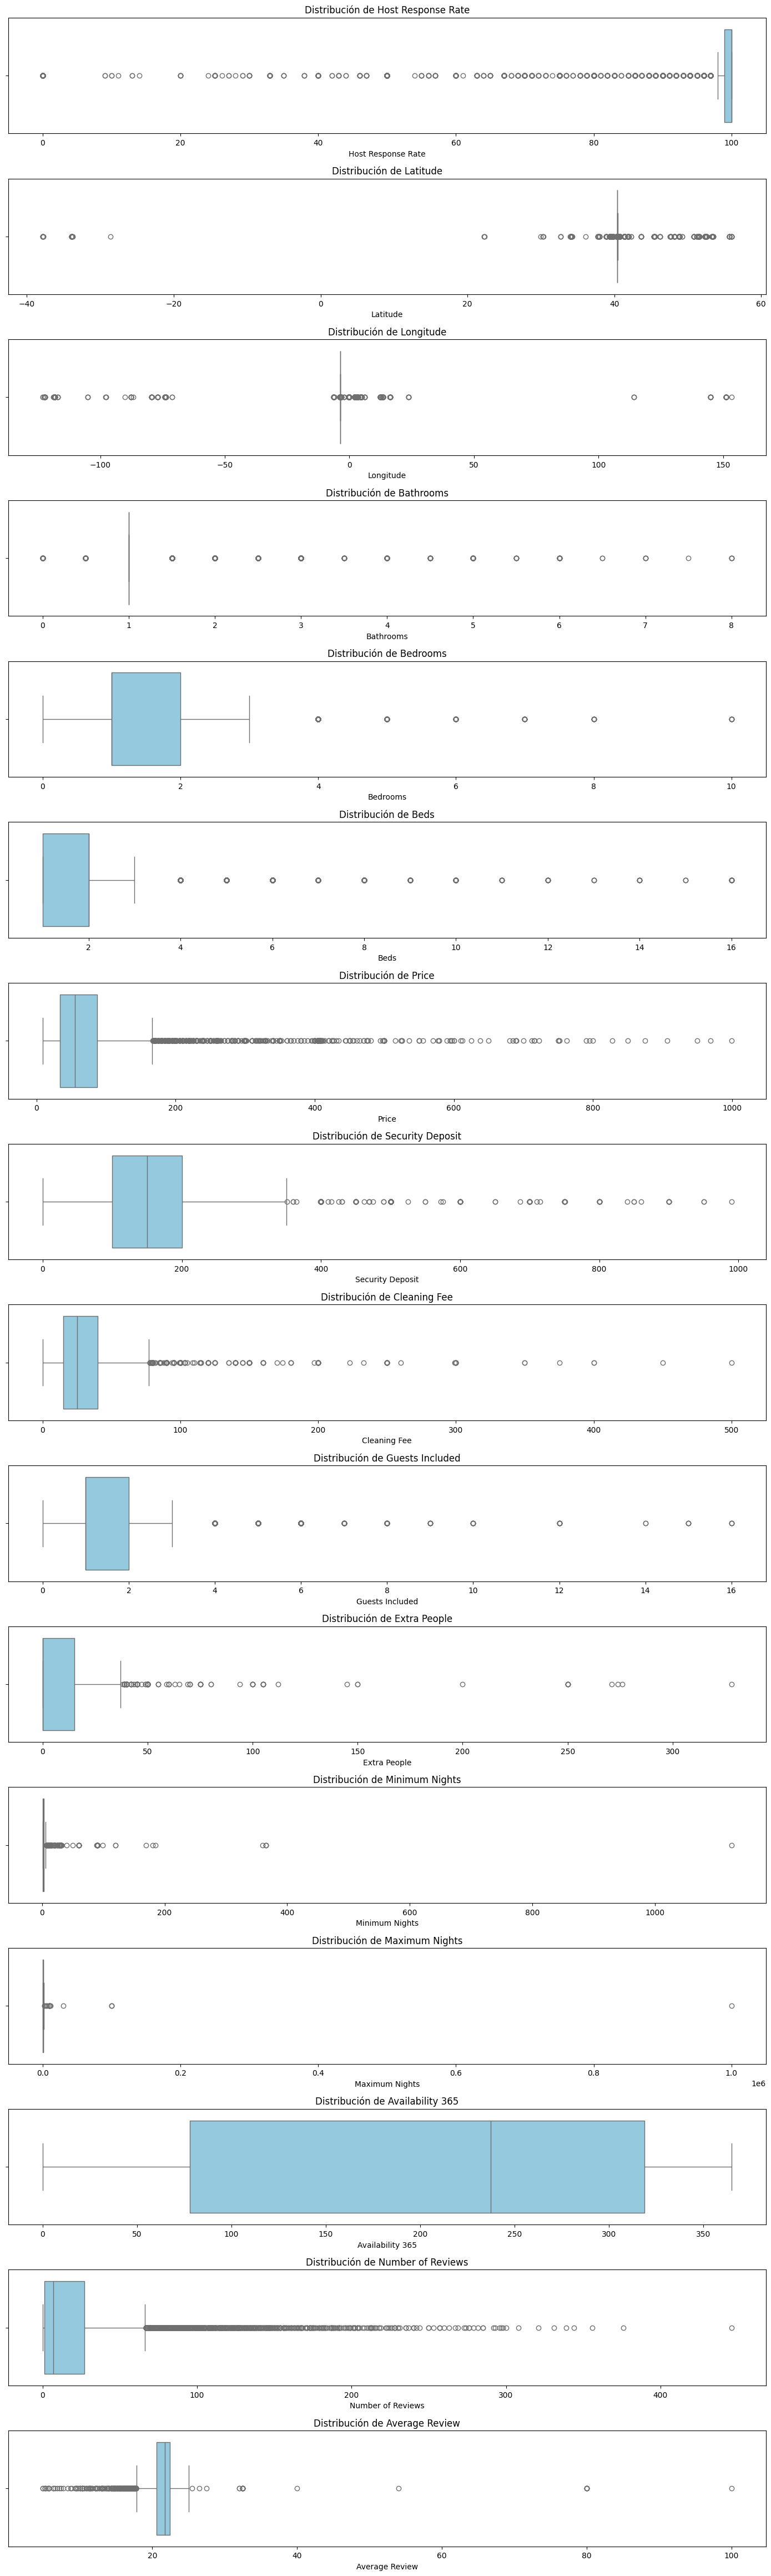

In [16]:
# Distribución de variables con boxplots
plt.figure(figsize=(14, len(df.columns) * 1.5))
for i, column in enumerate(df.select_dtypes(include=[np.number]).columns):
    plt.subplot(len(df.select_dtypes(include=[np.number]).columns), 1, i+1)
    sns.boxplot(x=df[column], color="skyblue")
    plt.title(f"Distribución de {column}")
    plt.tight_layout()

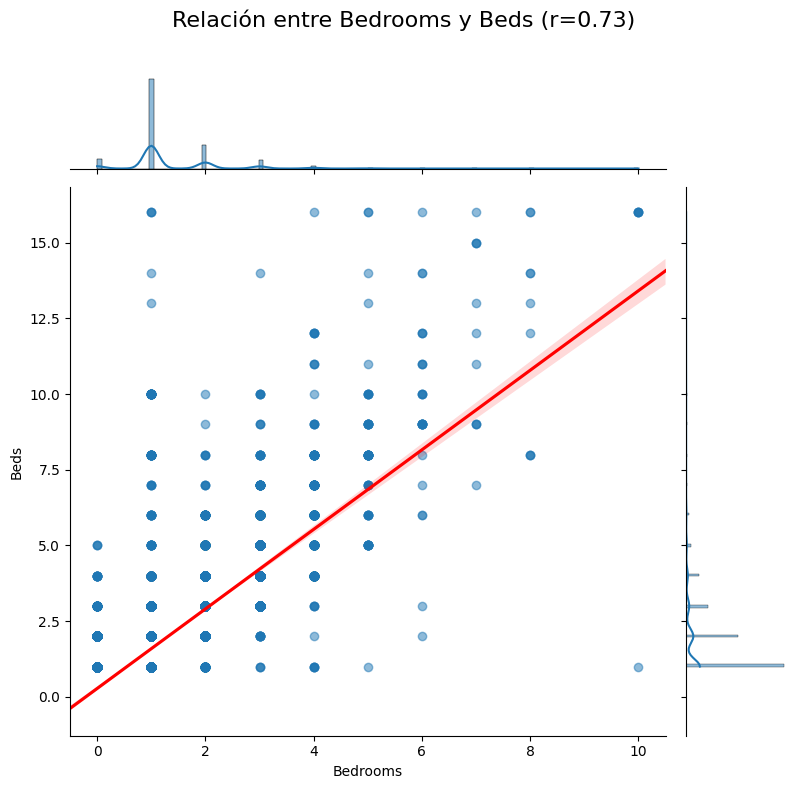

In [17]:
# Jointplot para las dos variables más correlacionadas
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) >= 2:
    corr_matrix = np.abs(df[numeric_cols].corr())
    np.fill_diagonal(corr_matrix.values, 0)
    max_corr_idx = np.unravel_index(corr_matrix.values.argmax(), corr_matrix.shape)
    var1, var2 = numeric_cols[max_corr_idx[0]], numeric_cols[max_corr_idx[1]]
    
    g = sns.jointplot(
        data=df,
        x=var1, y=var2,
        kind="reg",  # Regresión con dispersión
        truncate=False,
        scatter_kws=dict(alpha=0.5),
        line_kws=dict(color="red"),
        height=8
    )
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f'Relación entre {var1} y {var2} (r={corr_matrix.loc[var1, var2]:.2f})', 
                  fontsize=16)

Text(0.5, 1.0, 'Distribución original de Price')

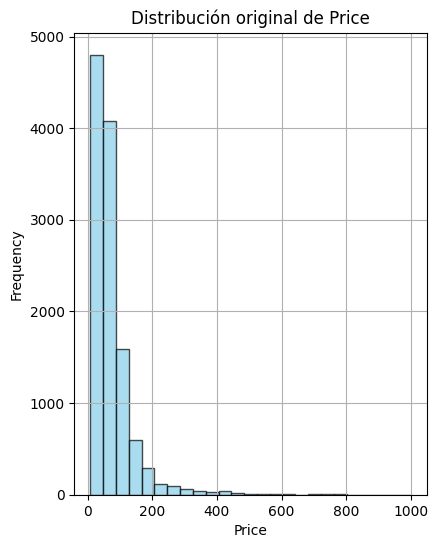

In [18]:
# Histograma del precio original
plt.subplot(1, 2, 1)
df['Price'].plot.hist(alpha=0.7, bins=25, grid=True, color='skyblue', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribución original de Price')

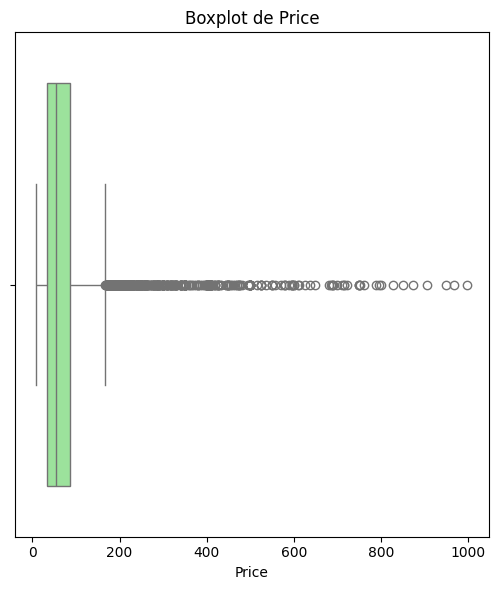

In [19]:
# Boxplot para ver outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Price'], color='lightgreen')
plt.xlabel('Price')
plt.title('Boxplot de Price')
plt.tight_layout()
plt.show()

In [20]:
# Análisis de valores extremos
high_price_count = len(df[df['Price'] > 200])
print(f"Valores con precio > 200: {high_price_count} de {len(df)} registros ({high_price_count/len(df)*100:.2f}%)")

medium_price_count = len(df[df['Price'] > 100])
print(f"Valores con precio > 100: {medium_price_count} de {len(df)} registros ({medium_price_count/len(df)*100:.2f}%)")


Valores con precio > 200: 462 de 11824 registros (3.91%)
Valores con precio > 100: 1969 de 11824 registros (16.65%)


Valores nulos en Price antes del filtro: 12
Registros después del filtro: 11280 (se eliminaron 544 registros)


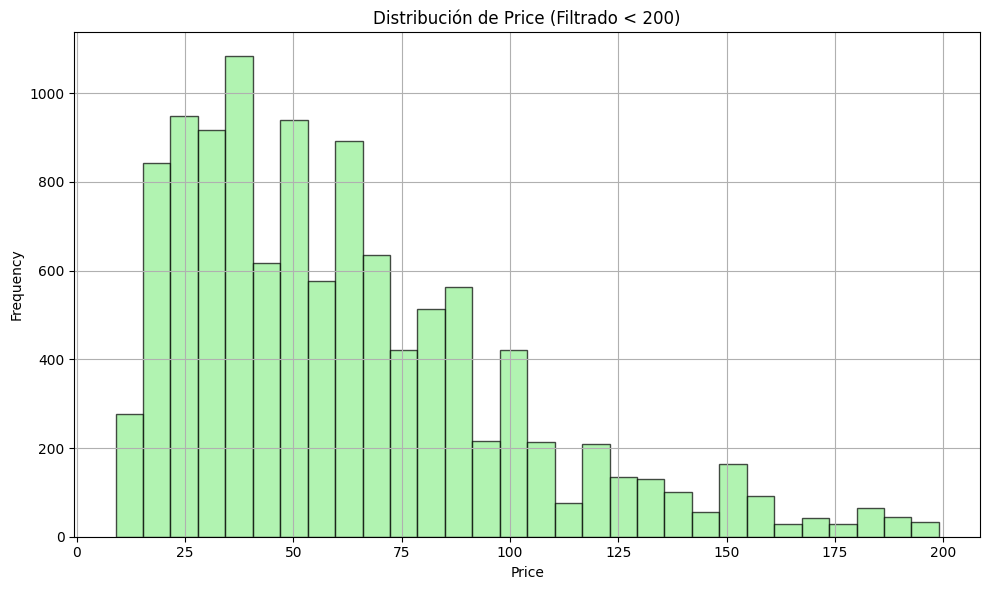

In [21]:
# Verificar nulos antes de filtrar
nulls_before = df['Price'].isna().sum()
print(f"Valores nulos en Price antes del filtro: {nulls_before}")

# Aplicar filtro y guardar en nuevo dataframe para comparar
df_filtered = df[df['Price'] < 200].copy()
print(f"Registros después del filtro: {len(df_filtered)} (se eliminaron {len(df) - len(df_filtered)} registros)")

# Comparación visual antes y después del filtro
plt.figure(figsize=(10, 6))
df_filtered['Price'].plot.hist(alpha=0.7, bins=30, grid=True, color='lightgreen', edgecolor='black')
plt.xlabel('Price')
plt.title('Distribución de Price (Filtrado < 200)')
plt.tight_layout()
plt.show()

In [22]:
#Estadísticas descriptivas comparativas
stats_comparison = pd.DataFrame({
    'Original': df['Price'].describe(),
    'Filtrado (<200)': df_filtered['Price'].describe()
})
print("\nEstadísticas comparativas de Price:")
print(stats_comparison)

# Asignar el dataframe filtrado
df = df_filtered.copy()
print(f"\nDimensiones finales del dataframe: {df.shape}")


Estadísticas comparativas de Price:
           Original  Filtrado (<200)
count  11812.000000     11280.000000
mean      73.633678        61.893351
std       72.260255        37.726507
min        9.000000         9.000000
25%       34.000000        32.000000
50%       55.000000        54.000000
75%       87.000000        80.000000
max      999.000000       199.000000

Dimensiones finales del dataframe: (11280, 31)


In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Host Response Rate,9841.0,94.752261,15.228684,0.000000,100.000000,100.000000,100.000000,100.000000
Latitude,11280.0,40.511092,4.423691,-37.851182,40.409759,40.419289,40.430648,55.956716
Longitude,11280.0,-3.866487,13.281586,-123.131344,-3.707569,-3.700941,-3.686334,153.371427
Bathrooms,11237.0,1.227908,0.551611,0.000000,1.000000,1.000000,1.000000,8.000000
Bedrooms,11261.0,1.265074,0.763264,0.000000,1.000000,1.000000,1.000000,10.000000
Beds,11246.0,1.919705,1.388016,1.000000,1.000000,1.000000,2.000000,16.000000
Price,11280.0,61.893351,37.726507,9.000000,32.000000,54.000000,80.000000,199.000000
Security Deposit,4751.0,182.309830,105.979654,0.000000,100.000000,150.000000,200.000000,990.000000
Cleaning Fee,6639.0,28.638952,20.379059,0.000000,15.000000,25.000000,35.000000,250.000000
Guests Included,11280.0,1.538209,1.003033,0.000000,1.000000,1.000000,2.000000,16.000000


In [24]:
#Featuring engineering

In [25]:
print(df.dtypes)

Experiences Offered              object
Host Since                       object
Host Response Time               object
Host Response Rate              float64
Host Verifications               object
Neighbourhood                    object
Neighbourhood Cleansed           object
Neighbourhood Group Cleansed     object
City                             object
Country Code                     object
Latitude                        float64
Longitude                       float64
Property Type                    object
Room Type                        object
Bathrooms                       float64
Bedrooms                        float64
Beds                            float64
Bed Type                         object
Amenities                        object
Price                           float64
Security Deposit                float64
Cleaning Fee                    float64
Guests Included                   int64
Extra People                      int64
Minimum Nights                    int64


In [26]:
# Creación de características
df["Final Neighbourhood"] = df["Neighbourhood Group Cleansed"].combine_first(df["Neighbourhood Cleansed"])

# Eliminar columnas originales en una sola operación
df.drop(columns=["Neighbourhood", "Neighbourhood Group Cleansed", "Neighbourhood Cleansed"], inplace=True)

# Procesar Features, Amenities y Host Verifications en una sola operación
list_columns = ['Features', 'Amenities', 'Host Verifications']

# Vectorizar operaciones (más rápido que apply con lambda)
df[list_columns] = df[list_columns].fillna('')

# Usando método vectorizado más eficiente
for col in list_columns:
    df[col] = df[col].str.count(',') + (df[col] != '')

In [27]:
# Eliminar filas con Host Since nulo (más eficiente que dropna)
df = df[df['Host Since'].notna()]

# Convertir a datetime
df['Host Since'] = pd.to_datetime(df['Host Since'])

# Calcular años de antigüedad usando .dt accessor 
df['Years Being Host'] = 2017 - df['Host Since'].dt.year

# Eliminar columna original
df.drop(columns=['Host Since'], inplace=True)

# Mostrar columnas resultantes
print("Columnas del DataFrame después de generar características:")
print(df.columns.tolist())

Columnas del DataFrame después de generar características:
['Experiences Offered', 'Host Response Time', 'Host Response Rate', 'Host Verifications', 'City', 'Country Code', 'Latitude', 'Longitude', 'Property Type', 'Room Type', 'Bathrooms', 'Bedrooms', 'Beds', 'Bed Type', 'Amenities', 'Price', 'Security Deposit', 'Cleaning Fee', 'Guests Included', 'Extra People', 'Minimum Nights', 'Maximum Nights', 'Availability 365', 'Number of Reviews', 'Cancellation Policy', 'Features', 'Average Review', 'Final Neighbourhood', 'Years Being Host']


In [28]:
# Filtrado en una sola operación
print(f"Registros con cero baños: {(df['Bathrooms'] == 0).sum()}")
print(f"Registros con precio cero: {(df['Price'] == 0).sum()}")

# Filtrado en una sola línea con condiciones combinadas
df = df[(df['Bathrooms'] != 0) & (df['Price'] != 0)]

# Identificar columnas categóricas
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Columnas categóricas encontradas: {categorical_columns}")

# Estadísticas de las columnas categóricas (resumido en una línea)
cat_stats = pd.DataFrame({
    'valores_únicos': df[categorical_columns].nunique(),
    'valores_nulos': df[categorical_columns].isna().sum()
})
print(cat_stats)

Registros con cero baños: 48
Registros con precio cero: 0
Columnas categóricas encontradas: ['Experiences Offered', 'Host Response Time', 'City', 'Country Code', 'Property Type', 'Room Type', 'Bed Type', 'Cancellation Policy', 'Final Neighbourhood']
                     valores_únicos  valores_nulos
Experiences Offered               5              0
Host Response Time                4           1418
City                            181              2
Country Code                     16              0
Property Type                    22              0
Room Type                         3              0
Bed Type                          5              0
Cancellation Policy               8              0
Final Neighbourhood             246              0


In [29]:
# Rellenar directamente con el valor más frecuente
df["Host Response Time"] = df["Host Response Time"].fillna(df["Host Response Time"].mode()[0])

# Eliminar directamente en una sola operación
columns_to_drop = ['Experiences Offered', 'City', 'Country Code']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Definir columnas categóricas a codificar
categorical = ['Host Response Time', 'Property Type', 'Room Type', 'Bed Type', 
               'Cancellation Policy', 'Final Neighbourhood']

# Aplicar mean encoding de forma más clara
mean_map = {}
for col in categorical:
    # Calcular media de precio por categoría
    group_means = df.groupby(col)['Price'].mean()
    
    # Aplicar mapeo
    df[col] = df[col].map(group_means)
    
    # Guardar mapeo para uso futuro
    mean_map[col] = group_means
    
    print(f"Codificada '{col}' con {len(group_means)} categorías")

Codificada 'Host Response Time' con 4 categorías
Codificada 'Property Type' con 22 categorías
Codificada 'Room Type' con 3 categorías
Codificada 'Bed Type' con 5 categorías
Codificada 'Cancellation Policy' con 8 categorías
Codificada 'Final Neighbourhood' con 246 categorías


In [30]:
# Mover Price a la primera posición
price_col = df.pop('Price')  # Extraer Price
df.insert(0, 'Price', price_col)  # Insertar al principio

# Rellenar valores faltantes con la media
if df.isna().any().any():
    missing_cols = df.columns[df.isna().any()].tolist()
    print(f"Columnas con valores faltantes: {missing_cols}")
    df = df.fillna(df.mean())
    print("Valores faltantes rellenados con la media de cada columna")

# Verificación final
print(f"\nDimensiones finales: {df.shape}")
print(f"¿Quedan valores nulos? {'Sí' if df.isna().any().any() else 'No'}")

Columnas con valores faltantes: ['Host Response Rate', 'Bathrooms', 'Bedrooms', 'Beds', 'Security Deposit', 'Cleaning Fee', 'Average Review']
Valores faltantes rellenados con la media de cada columna

Dimensiones finales: (11230, 26)
¿Quedan valores nulos? No


In [31]:
data = df.values

# Separar características y objetivo
y_train = data[:, 0:1]     # Primera columna (Price)
X_train = data[:, 1:]      # Resto de columnas
feature_names = df.columns[1:]

# Escalar los datos
scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

# Imprimir dimensiones (corregido)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")

Dimensiones de X_train: (11230, 25)
Dimensiones de y_train: (11230, 1)


In [32]:
print("\nEstadísticas después del escalado:")
print(f"Media de X_train_scaled: {np.mean(X_train_scaled, axis=0)[:5]}...")  # Primeros 5 valores
print(f"Desviación estándar de X_train_scaled: {np.std(X_train_scaled, axis=0)[:5]}...")



Estadísticas después del escalado:
Media de X_train_scaled: [-2.40537381e-14  1.43943430e-16 -3.22053653e-16 -3.66343939e-16
 -2.40432983e-17]...
Desviación estándar de X_train_scaled: [1. 1. 1. 1. 1.]...


In [33]:
alpha_vector = np.logspace(-1.5,-0.5,20)

param_grid = {'alpha': alpha_vector }
grid = GridSearchCV(Lasso(), scoring= 'neg_mean_squared_error', param_grid=param_grid, cv = 10)
grid.fit(X_train_scaled, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation score: -518.782
best parameters: {'alpha': 0.09412049672680665}


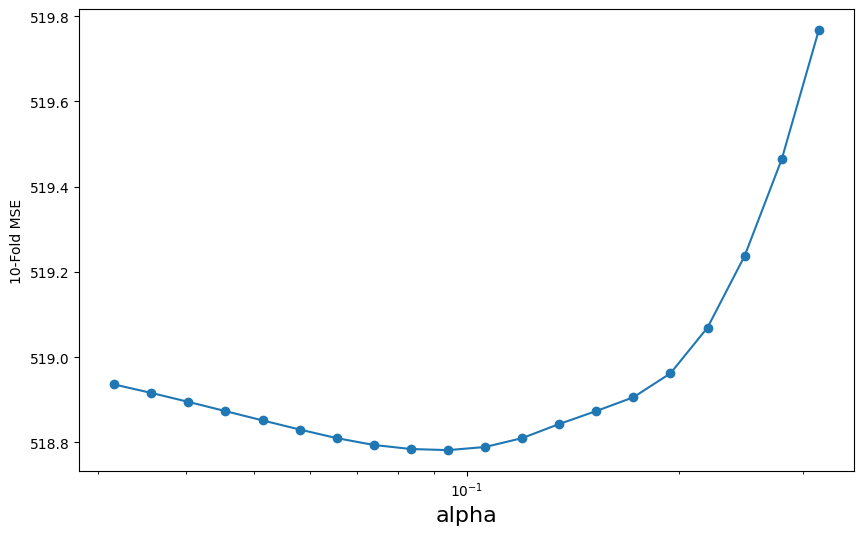

In [34]:
scores = -1*np.array(grid.cv_results_['mean_test_score'])
plt.semilogx(alpha_vector,scores,'-o')
plt.xlabel('alpha',fontsize=16)
plt.ylabel('10-Fold MSE')
plt.show()

In [35]:
df_test = pd.read_csv('./test.csv', sep=';', decimal='.')

not_useful_columns = [
    'ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Thumbnail Url', 'Medium Url', 
    'Picture Url', 'XL Picture Url', 'Host ID', 'Host URL', 'Host Name', 
    'Host Thumbnail Url', 'Host Picture Url', 'Host Neighbourhood', 'Weekly Price', 
    'Monthly Price', 'Calendar Updated', 'Calendar last Scraped', 'First Review', 
    'Last Review', 'Reviews per Month', 'Geolocation', 'Calculated host listings count',
    'Host Listings Count', 'Host Total Listings Count'
]
somehow_useful_columns_but_droppable_anyway = ['Name', 'Summary', 'Space', 'Description',
       'Neighborhood Overview', 'Notes', 'Transit', 'Access', 'Interaction', 'House Rules',
       'Host Location', 'Host About'
]
columns_with_too_many_missing_values = [
    'Host Acceptance Rate', 'Square Feet', 'Has Availability', 'License', 'Jurisdiction Names'
]

df_test.drop(not_useful_columns, axis=1, inplace=True)
df_test.drop(somehow_useful_columns_but_droppable_anyway, axis=1, inplace=True)
df_test.drop(['Street', 'State', 'Market', 'Smart Location', 'Country', 'Zipcode'], axis=1, inplace=True)
df_test.drop(columns_with_too_many_missing_values, axis=1, inplace=True)

reviews = df_test.loc[: , "Review Scores Rating":"Review Scores Value"]
df_test['Average Review'] = reviews.mean(axis=1)

df_test.drop(['Availability 30', 'Availability 60', 'Availability 90', 'Review Scores Rating', 
         'Review Scores Accuracy', 'Review Scores Cleanliness', 'Review Scores Checkin',
       'Review Scores Communication', 'Review Scores Location', 'Review Scores Value',
        'Accommodates'], axis=1, inplace=True)

df_test = df_test[df_test['Price'] < 200]

df_test["Final Neighbourhood"] = df_test["Neighbourhood Group Cleansed"].fillna(df_test["Neighbourhood Cleansed"])
df_test.drop(["Neighbourhood", "Neighbourhood Group Cleansed", "Neighbourhood Cleansed"], axis=1, inplace=True)

df_test['Features'].fillna("", inplace=True) # rellenamos los huecos con cadenas vacías
df_test['Amenities'].fillna("", inplace=True)
df_test['Host Verifications'].fillna("", inplace=True)

df_test['Features'] = df_test['Features'].apply(lambda x: len(str(x).split(',')))
df_test['Amenities'] = df_test['Amenities'].apply(lambda x: len(str(x).split(',')))
df_test['Host Verifications'] = df_test['Host Verifications'].apply(lambda x: len(str(x).split(',')))

df_test.dropna(subset=['Host Since'], inplace=True)
df_test['Host Since'] = df_test['Host Since'].apply(lambda x: datetime.strptime(str(x),'%Y-%m-%d'))
df_test['Years Being Host'] = df_test['Host Since'].apply(lambda x: 2017 - x.year)
df_test.drop(['Host Since'], axis=1, inplace=True)

df_test = df_test[df_test['Bathrooms'] != 0]
df_test = df_test[df_test['Price'] != 0]

df_test["Host Response Time"].fillna(df["Host Response Time"].mode()[0], inplace=True)
df_test.drop(['Experiences Offered'], axis=1, inplace=True)
df_test.drop(['City', 'Country Code'], axis=1, inplace=True)

categorical = ['Host Response Time', 'Property Type', 'Room Type', 'Bed Type', 'Cancellation Policy',
 'Final Neighbourhood'
]

# Categorizamos con los datos de train!
for c in categorical:
    df_test[c] = df_test[c].map(mean_map[c])

# Comprobamos que no quedan valores no numéricos
df[categorical].dtypes


Host Response Time     float64
Property Type          float64
Room Type              float64
Bed Type               float64
Cancellation Policy    float64
Final Neighbourhood    float64
dtype: object

In [36]:
cols = df_test.columns.tolist()
cols.insert(0, cols.pop(cols.index('Price')))
df_test = df_test[cols]

df_test.fillna(df.mean(), inplace=True)

print(df.shape, df_test.shape)

(11230, 26) (2806, 26)


In [37]:
data_test = df_test.values

y_test = data_test[:,0:1]     # nos quedamos con la 1ª columna, price
X_test = data_test[:,1:]      # nos quedamos con el resto

feature_names_test = df_test.columns[1:]
XtestScaled = scaler.transform(X_test) 

In [38]:
alpha_optimo = grid.best_params_['alpha']#*10 #*100
lasso = Lasso(alpha = alpha_optimo).fit(X_train_scaled,y_train)

ytrainLasso = lasso.predict(X_train_scaled)
ytestLasso  = lasso.predict(XtestScaled)
mseTrainModelLasso = mean_squared_error(y_train,ytrainLasso)
mseTestModelLasso = mean_squared_error(y_test,ytestLasso)

print('MSE Modelo Lasso (train): %0.5g' % mseTrainModelLasso)
print('MSE Modelo Lasso (test) : %0.5g' % mseTestModelLasso)

w = lasso.coef_
for f,wi in zip(feature_names,w):
    print(f,wi)

MSE Modelo Lasso (train): 514.22
MSE Modelo Lasso (test) : 528.74
Host Response Time 0.34253691835411154
Host Response Rate -1.4076354642147546
Host Verifications -0.8892765255637534
Latitude -0.5625092635589214
Longitude -0.6265865264591699
Property Type 0.0
Room Type 15.75042478621997
Bathrooms 2.315875617695039
Bedrooms 7.588102463378871
Beds 1.5663559354628203
Bed Type 0.2046265207426693
Amenities 2.3844386634180395
Security Deposit 2.5714038274223046
Cleaning Fee 5.894998984324344
Guests Included 3.246911225125025
Extra People -0.18095543058206257
Minimum Nights -0.6531602576348451
Maximum Nights -0.0
Availability 365 1.5741743019232486
Number of Reviews -3.2114785281559417
Cancellation Policy -0.660698215243195
Features 1.0206122579423733
Average Review 1.5304986355394754
Final Neighbourhood 9.598862403789235
Years Being Host 0.6128895404837438


In [39]:
# Obtener coeficientes y asociarlos a sus nombres
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': lasso.coef_
})

# Agregar columna con valor absoluto
coef_df['Importancia'] = np.abs(coef_df['Coeficiente'])

# Filtrar y ordenar
coef_df = coef_df[coef_df['Coeficiente'] != 0].sort_values(by='Importancia', ascending=False)

# Mostrar top 10
print("\nTop features más importantes del modelo Lasso:")
print(coef_df.head(10))


Top features más importantes del modelo Lasso:
                Feature  Coeficiente  Importancia
6             Room Type    15.750425    15.750425
23  Final Neighbourhood     9.598862     9.598862
8              Bedrooms     7.588102     7.588102
13         Cleaning Fee     5.894999     5.894999
14      Guests Included     3.246911     3.246911
19    Number of Reviews    -3.211479     3.211479
12     Security Deposit     2.571404     2.571404
11            Amenities     2.384439     2.384439
7             Bathrooms     2.315876     2.315876
18     Availability 365     1.574174     1.574174


In [40]:
# Definir modelos y grids
models_to_evaluate = {
    'Lasso': {
        'model': Lasso(),
        'params': {'alpha': np.logspace(-2, 0, 10)}
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': np.logspace(-2, 2, 10)}
    },
    'ElasticNet': {
        'model': ElasticNet(max_iter=10000),
        'params': {
            'alpha': np.logspace(-2, 0, 5),
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(max_depth=3),
        'params': {
            'n_estimators': [100, 500],
            'learning_rate': [0.01, 0.1]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(oob_score=True),
        'params': {
            'n_estimators': [100, 500],
            'max_depth': [10, 20],
            'min_samples_split': [2, 5]
        }
    }
}

# Inicializar listas de resultados
results_list = []
trained_models = {}

# Entrenamiento y evaluación
for name, config in models_to_evaluate.items():
    print(f"\nEntrenando modelo: {name}")
    start = time.time()
    
    # GridSearch
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train_scaled, y_train.ravel())

    best_params = grid.best_params_
    model = grid.best_estimator_

    # Para Lasso: reconstruir con alpha_optimo
    if name == 'Lasso':
        alpha_optimo = best_params['alpha']
        model = Lasso(alpha=alpha_optimo)
        model.fit(X_train_scaled, y_train.ravel())

    # Predecir
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(XtestScaled)

    # Métricas
    results_list.append({
        'Modelo': name,
        'Parámetros': best_params,
        'Train MSE': mean_squared_error(y_train, y_pred_train),
        'Test MSE': mean_squared_error(y_test, y_pred_test),
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'Median AE': median_absolute_error(y_test, y_pred_test),
        'CV MSE': -grid.best_score_,
        'Tiempo (s)': time.time() - start
    })

    trained_models[name] = model

# Crear DataFrame final
results_df = pd.DataFrame(results_list).sort_values("Test MSE")
display(results_df)


Entrenando modelo: Lasso

Entrenando modelo: Ridge

Entrenando modelo: ElasticNet

Entrenando modelo: Gradient Boosting

Entrenando modelo: Random Forest


,Modelo,Parámetros,Train MSE,Test MSE,Train R²,Test R²,MAE,Median AE,CV MSE,Tiempo (s)
3,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 500}",254.191592,374.215752,0.821550,0.735504,13.297573,9.235344,356.987366,20.437474
4,Random Forest,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",65.889986,391.292987,0.953743,0.723434,13.515861,8.782181,374.530168,92.961913
1,Ridge,{'alpha': 100.0},513.957468,527.979723,0.639187,0.626824,16.216628,11.541619,518.411805,0.258702
2,ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.9}",514.329000,528.755212,0.638926,0.626276,16.230166,11.629044,518.033330,0.456912
0,Lasso,{'alpha': 0.1291549665014884},514.472749,529.120801,0.638825,0.626017,16.238938,11.590023,518.033579,1.252517


Mejor modelo: Gradient Boosting
- Mejor desempeño general (Test MSE, Test R², MAE).
- Excelente relación calidad-tiempo (20s).


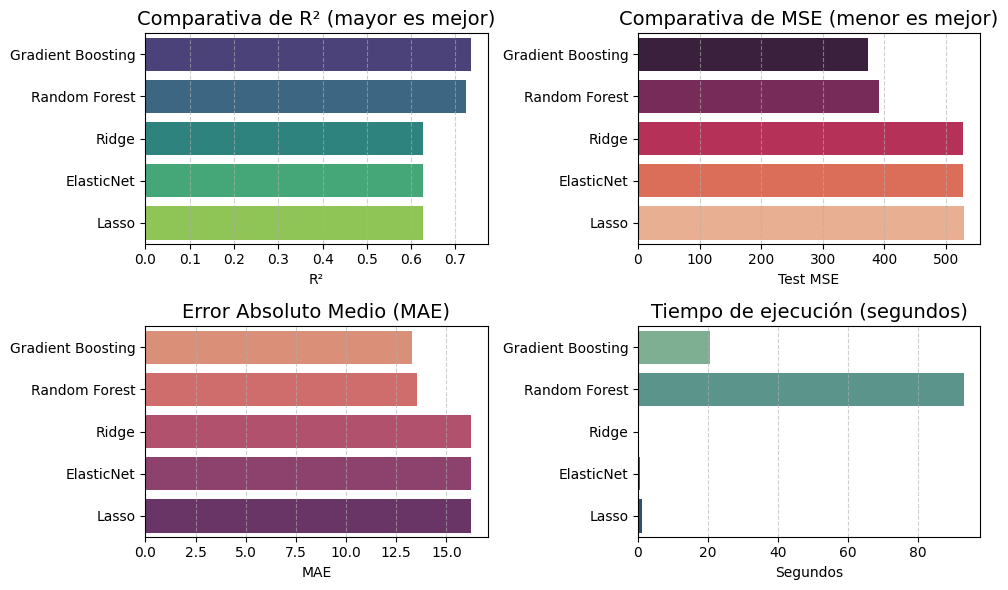

In [41]:
# R²
plt.subplot(2, 2, 1)
sns.barplot(x='Test R²', y='Modelo', data=results_df, palette='viridis')
plt.title('Comparativa de R² (mayor es mejor)', fontsize=14)
plt.xlabel('R²'); plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# MSE
plt.subplot(2, 2, 2)
sns.barplot(x='Test MSE', y='Modelo', data=results_df, palette='rocket')
plt.title('Comparativa de MSE (menor es mejor)', fontsize=14)
plt.xlabel('Test MSE'); plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# MAE
plt.subplot(2, 2, 3)
sns.barplot(x='MAE', y='Modelo', data=results_df, palette='flare')
plt.title('Error Absoluto Medio (MAE)', fontsize=14)
plt.xlabel('MAE'); plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Tiempo de ejecución
plt.subplot(2, 2, 4)
sns.barplot(x='Tiempo (s)', y='Modelo', data=results_df, palette='crest')
plt.title('Tiempo de ejecución (segundos)', fontsize=14)
plt.xlabel('Segundos'); plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Top 10 features más importantes - Gradient Boosting


,Feature,Importancia
6,Room Type,0.414669
7,Bathrooms,0.122243
23,Final Neighbourhood,0.103525
8,Bedrooms,0.099821
13,Cleaning Fee,0.060883
3,Latitude,0.027917
9,Beds,0.025170
4,Longitude,0.017606
15,Extra People,0.017547
14,Guests Included,0.017498


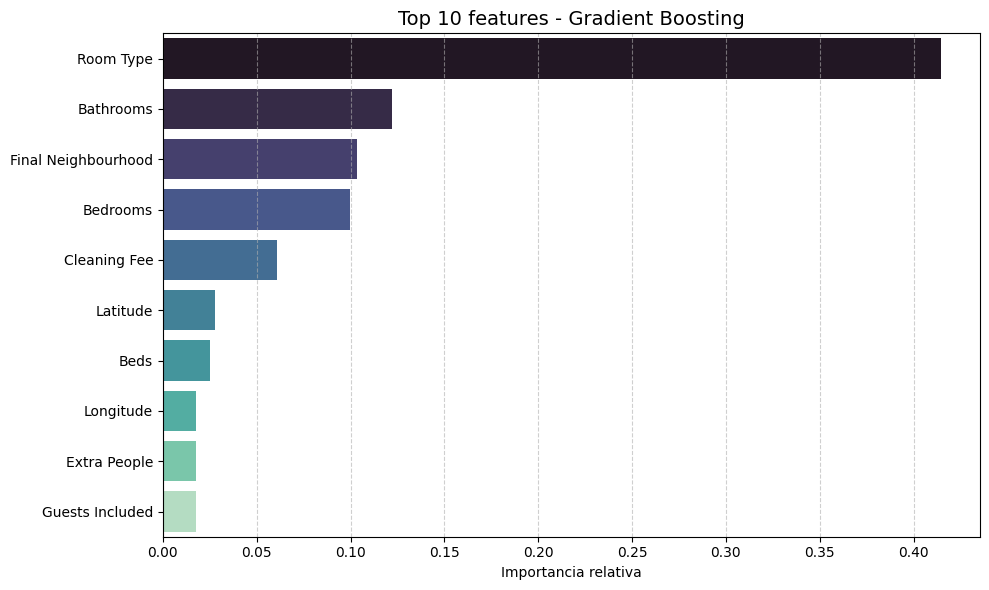

In [42]:
# Obtener el mejor modelo
best_model_name = results_df.iloc[0]['Modelo']
best_model = trained_models[best_model_name]

# Verificar si tiene atributo feature_importances_
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importancia': importances
    }).sort_values(by='Importancia', ascending=False)

    # Mostrar top 10
    print(f"\nTop 10 features más importantes - {best_model_name}")
    display(importance_df.head(10))

    # Visualización
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importancia', y='Feature', data=importance_df.head(10), palette='mako')
    plt.title(f'Top 10 features - {best_model_name}', fontsize=14)
    plt.xlabel('Importancia relativa'); plt.ylabel('')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importancia': importances
    }).sort_values(by='Importancia', ascending=False)

    print(f"\nTop 10 coeficientes más grandes - {best_model_name}")
    display(importance_df.head(10))

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importancia', y='Feature', data=importance_df.head(10), palette='mako')
    plt.title(f'Top 10 coeficientes - {best_model_name}', fontsize=14)
    plt.xlabel('Valor absoluto del coeficiente'); plt.ylabel('')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ El modelo '{best_model_name}' no tiene atributos interpretables directamente.")

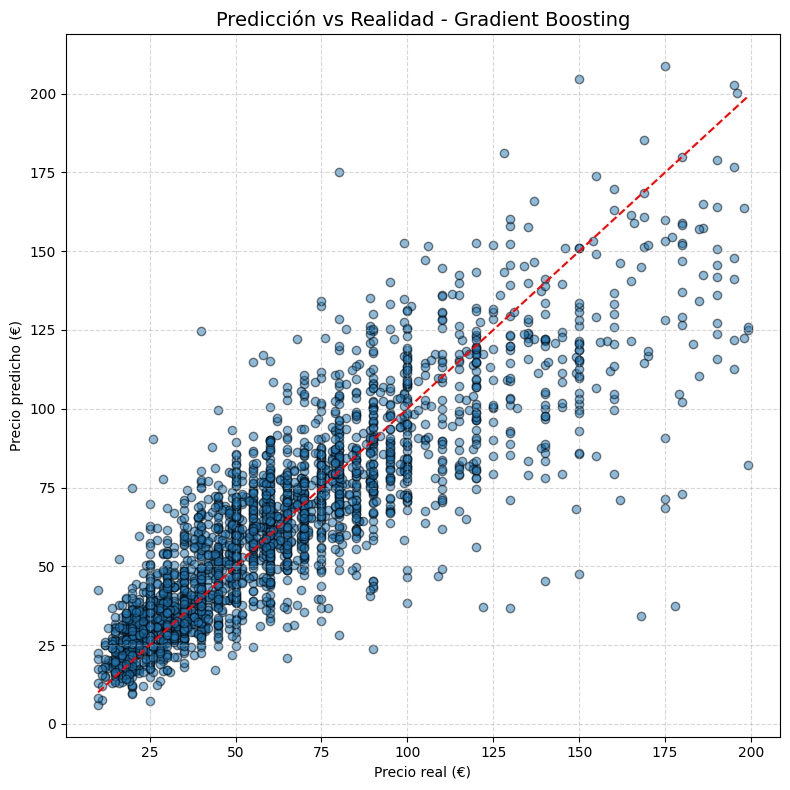

In [43]:
# Predicciones con el mejor modelo
y_pred = best_model.predict(XtestScaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Precio real (€)')
plt.ylabel('Precio predicho (€)')
plt.title(f'Predicción vs Realidad - {best_model_name}', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

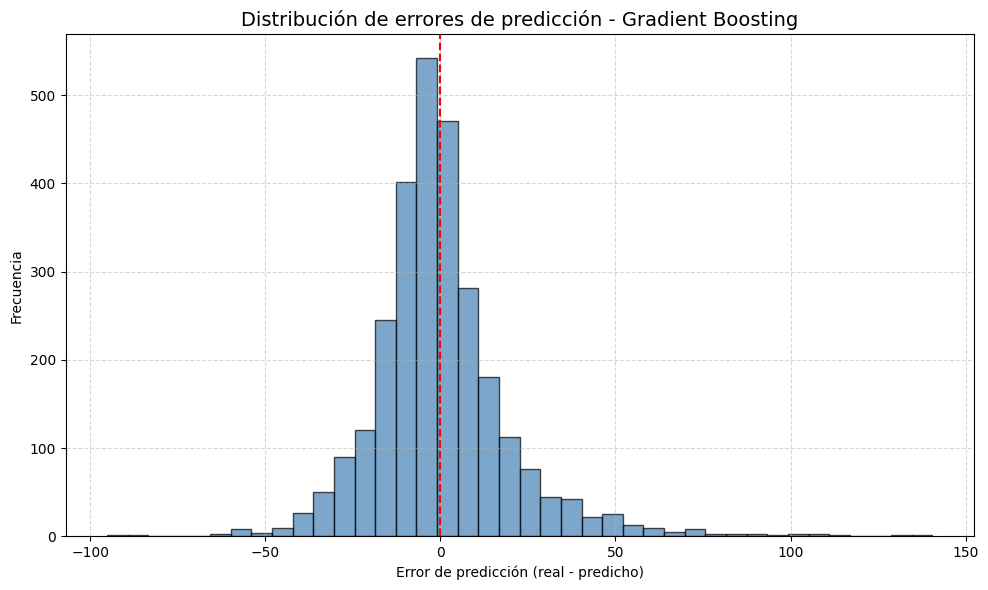

In [44]:
errors = y_test.ravel() - y_pred

plt.figure(figsize=(10, 6))
plt.hist(errors, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title(f'Distribución de errores de predicción - {best_model_name}', fontsize=14)
plt.xlabel('Error de predicción (real - predicho)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()